# Applying Stylometry to the Unabomber Case

## Background 

- In 1996 infamous mathematician Ted Kaczynski, also known as the Unabomber, was arrested on domestic terrorism charges.
- Part of what led to his arrest was the FBI's use of linguistics analysis of his writing.
- This was before many of the advances in stylometry and much of this analysis was done manually.
- In this report we will use the evolving field of stylometry, combined with machine learning and data visualization to perform our own analysis algorithmically.

## Ethical Concerns
- Ted Kaczynski killed people in order to bring attention to his critiques on society. 
- Ted Kaczynski also lived in a representative democracy that, while imperfect, allowed for legitimate outlets to express those critiques.
- Hiding in a cabin and mailing bombs to university professors is *not* one of those legitimate outlets. It is an extraordinary act of cowardice.
- We will not focus on his beliefs in this report but rather the applied use of stylometry.

## Imports

In [1]:
from bs4 import BeautifulSoup
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from matplotlib.colors import ListedColormap
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import plotly.express as px
import re
import plotly.offline as py
py.init_notebook_mode(connected=True)

## Parsing
- The FBI separated its documents into T-Docs and U-Docs.
- The T-Docs are letters his brother sent in that include their correspondence back and forth.
- The U-Docs are letters Kaczynski mailed anonymously to news organizations.
- In addition to the letters Kaczynski also wrote a 35,000 word manifesto.
- As of right now the best resource to obtain these documents is through a website called <https://thetedkarchive.com>.
- Below is the code use to extract these documents from the HTML that contains them.
- We also include letters from his brother Dave, his manifesto, and letters from Charles Darwin as a control.

### Unabomber Letters

In [2]:
# https://www.thetedkarchive.com/library/theo-slade-the-bombings-communications-of-ted-kaczynski-as-part-of-his-terror-campaign
# extract udocs from html
rows = []  
with open("./u-docs.html") as f:
    soup = BeautifulSoup(f, "html.parser")
for p in soup.find_all("p"):
    if not p.get_text(strip=True).startswith("Ted:"):
        continue

    blk = p.find_next("blockquote")
    if not blk:
        continue
    blkText = blk.get_text(strip=True, separator=" ")
    rows.append(("UB Letters", blkText))


### Unabomber Manifesto

In [3]:
# https://archive.nytimes.com/www.nytimes.com/library/national/unabom-manifesto-1.html
# extract uman from html
with open("./u-man.html") as f:
    soup = BeautifulSoup(f, "html.parser")
for p in soup.find_all("p"):
    text = p.get_text(strip=True, separator=" ")
    if re.match(r"\d+\.", text):
        rows.append(("UB Man", text))



### Ted and Dave Letters

In [4]:
# extract tdocs from html
with open("./t-docs.html") as f:
    soup = BeautifulSoup(f, "html.parser")
for h4 in soup.find_all("h4"):
    h4Text = h4.get_text()
    if h4Text.startswith("From Ted to") and "(T-" in h4Text:
        contents = []
        for sib in h4.next_siblings:
            if sib.name == "h4" or (sib.name == "h3" and sib.get_text() == "Sources"):
                break
            contents.append(sib.get_text(strip=True, separator=" "))
        rows.append(("Ted Letters", " ".join(contents)))
    if h4Text.startswith("From Dave"):
        contents = []
        for sib in h4.next_siblings:
            if sib.name == "h4" or (sib.name == "h3" and sib.get_text() == "Sources"):
                break
            contents.append(sib.get_text(strip=True, separator=" "))
        rows.append(("Dave Letters", " ".join(contents)))


### Charles Darwin Letters

In [5]:

# darwin letters for a control
# https://www.gutenberg.org/
with open("./darwin.html") as f:
    soup = BeautifulSoup(f, "html.parser")

p_tags = soup.find_all("p")

current_letter = None
contents = []

for p in p_tags:
    text = p.get_text(strip=True, separator=" ")

    if text.startswith("LETTER"):
        # save previous letter first
        if current_letter is not None and contents:
            rows.append(("Darwin Control", " ".join(contents)))

        # start new collection
        current_letter = text
        contents = []
        continue

    # inside letter
    if current_letter is not None:
        contents.append(text)

# save last letter
if current_letter is not None and contents:
    rows.append(("Darwin Control", " ".join(contents)))

df = pd.DataFrame(rows, columns=["Doc Type", "rawTxt"])


## Plot 1
In this first plot we run a TF-IDF algorithm over the words while at the same time removing stop words. Stop words include filler words such as "the" and "is". The was this algorithm works is by counting the frequency of each word in the document and scaling it by its inverse document frequency. Inverse document frequency simply punishes words commonly appear in the entire corpus. Finally, we are left with a 5000 parameter array. We can't visualize 5000 dimension, so we squeeze this down to 3 dimensions by using principal component analysis. It basically takes a bunch of dimensions and correlates them together.

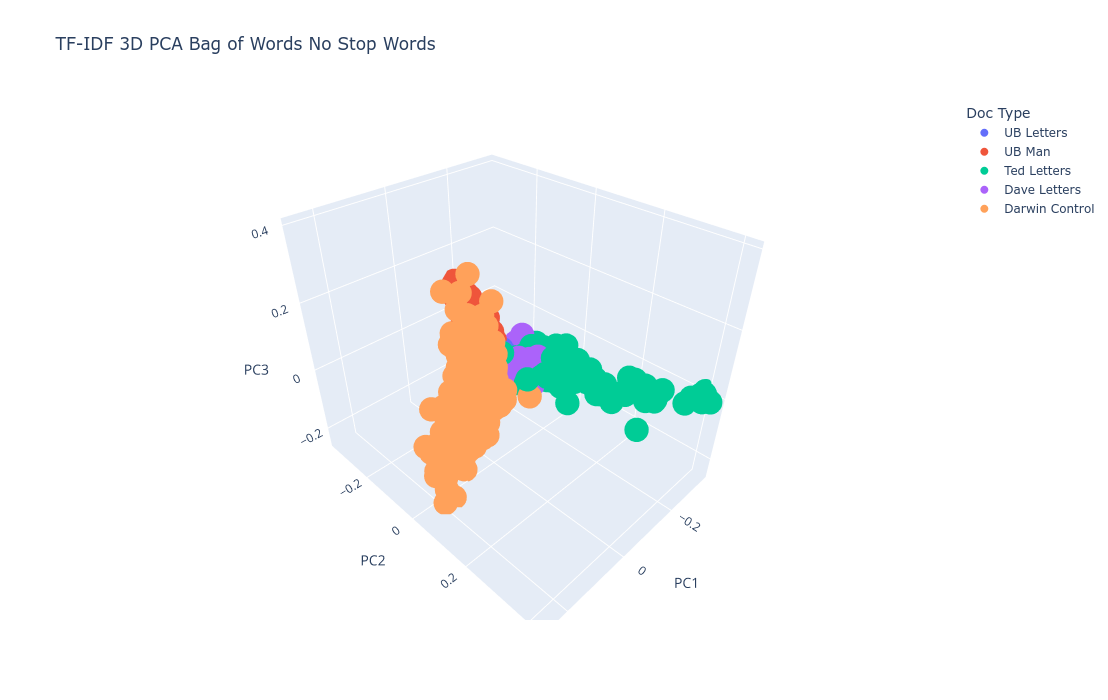

In [6]:

def clean(text):
    text = text.lower()
    tokens = text.split()
    return " ".join(tokens)


df["cleanTxt"] = df["rawTxt"].apply(clean)

# TF-IDF TO 3D PCA
# good for content similarity
# https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/
# https://www.ibm.com/think/topics/principal-component-analysis
X = TfidfVectorizer(max_features=5000, stop_words="english").fit_transform(
    df["cleanTxt"]
)

pca = PCA(n_components=3)
pcs = pca.fit_transform(X.toarray())

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]
df["PC3"] = pcs[:, 2]

fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Doc Type", height=700,
    title="TF-IDF 3D PCA Bag of Words No Stop Words",
)

fig.show()


Dr. James O'Sullivan is a researcher in the field of computer-assisted text analysis. In the video below he states that when you remove stop words what you are left with is the content of the text rather than the writing style. We can see that in our visualization with the Darwin letters being orthogonal to the rest of the corpus. We also notice some overlap between the Ted letters and his brother's letters. This is expected as they are communicating back and forth on the same subjects.

- <https://www.youtube.com/watch?v=dnFgVc8UNkE>

## Plot 2
In this plot we take the average sentence length of each document and plot it using a box and whisker plot.

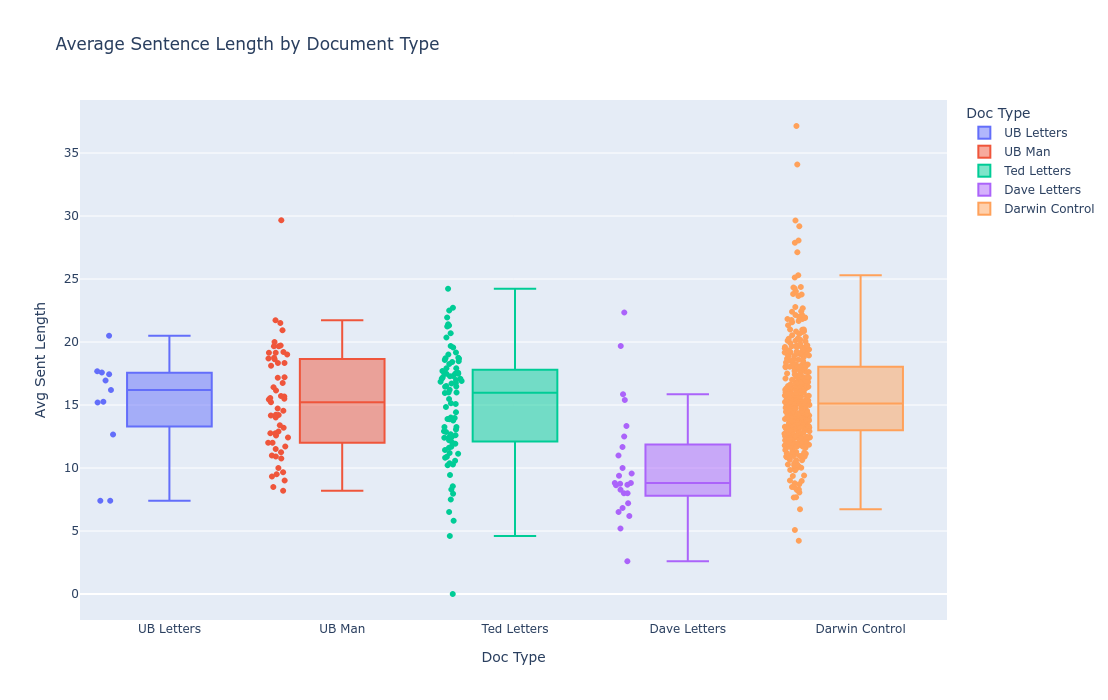

In [7]:

# avg sent len box whisker plot
def avgSent(text):
    sents = re.split(r"[.!?]", text)
    lengths = [len(s.split()) for s in sents]
    return sum(lengths) / len(lengths) if lengths else 0


df["Avg Sent Length"] = df["cleanTxt"].apply(avgSent)

# plotly box whisker on avg sent for each doc type
fig = px.box(
    df,
    x="Doc Type",
    y="Avg Sent Length",
    title="Average Sentence Length by Document Type",
    color="Doc Type", height=700,
    points="all",
)

fig.show()

Here we notice a departure in styles between the two brothers with Ted having a longer average sentence length.

## Plot 3

> In his study, Reference GrieveGrieve (2007) finds that character n-grams (up to about 6-grams) can be useful as authorship markers along with various measures of word and punctuation distribution, and shows how with a decreasing number of candidate authors in a closed set, other features, including some measures of lexical richness and average word and sentence length, might have some role to play, but generally lack a strong predictive power. - Tim Grant

In this plot we use the same algorithm we used in the first plot, but this time we partition the data in two to six character partitions instead of words. We also leave in the stop words this time. This is said to measure the writing style more than just the content. Its worth noting that in the original linguistic analysis common misspellings in the Ted/Unabomber documents was one of the determining factors.

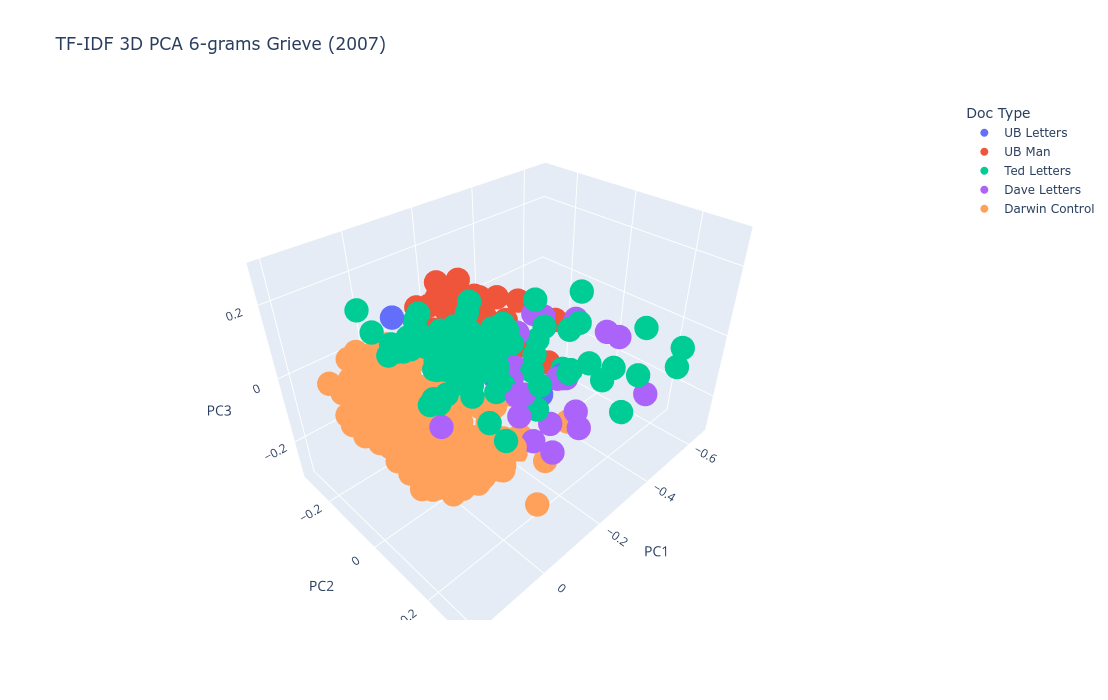

In [8]:
# https://www.cambridge.org/core/elements/idea-of-progress-in-forensic-authorship-analysis/6A4F7668B4831CCD7DBF74DECA3EBA06
X = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 6),
    min_df=2,
    max_features=10000,
).fit_transform(df["rawTxt"])

pca = PCA(n_components=3)
pcs = pca.fit_transform(X.toarray())

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]
df["PC3"] = pcs[:, 2]

fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Doc Type", height=700,
    title="TF-IDF 3D PCA 6-grams Grieve (2007)",
)
fig.show()


Here we see clustering in the manifesto and Darwin control documents. Toggling these two datasets off, we also see tighter clustering between some Unabomber letters and Ted letters. However, we also some Unabomber letters are close to the brother's letters.

## Plot 4

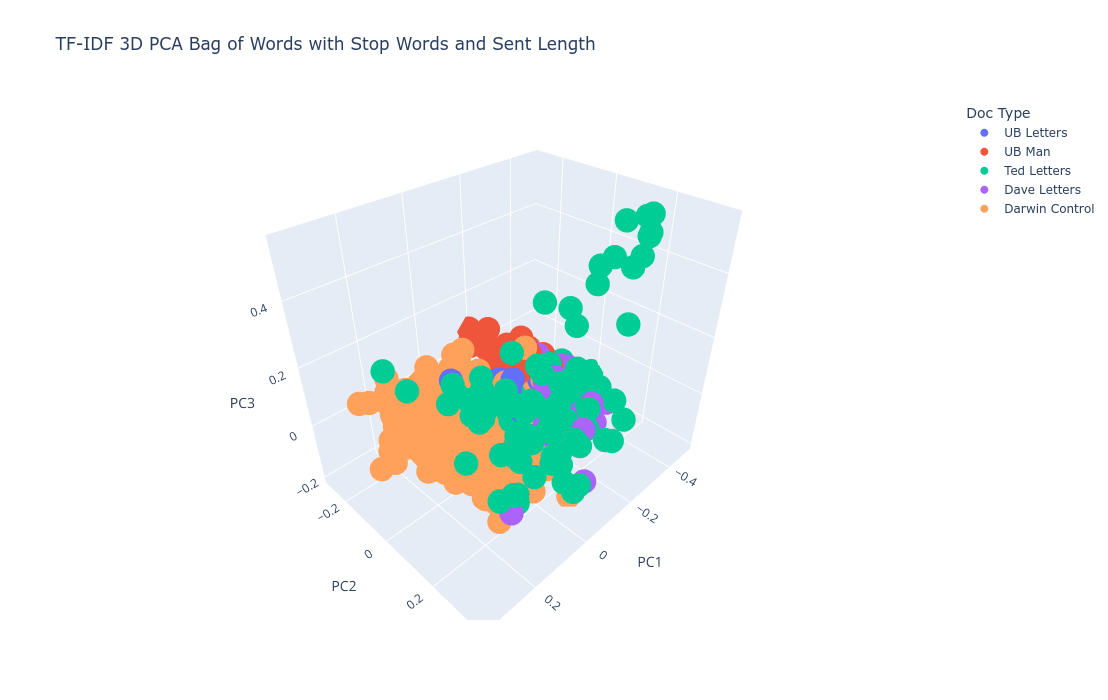

In [9]:
X = TfidfVectorizer(max_features=5000).fit_transform(df["cleanTxt"])

pca = PCA(n_components=3)
pcs = pca.fit_transform(X, df[["Avg Sent Length"]].to_numpy())

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]
df["PC3"] = pcs[:, 2]

fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Doc Type", height=700,
    title="TF-IDF 3D PCA Bag of Words with Stop Words and Sent Length",
)

fig.show()


## Plot 5
The code below is mostly not my own. It has been adapted from Dr. O'Sullivan's November 2025 paper in Nature. In it, he uses Burrow's Delta in combination with a dendrogram diagram to analyze human versus AI generated texts. I have adapted the `load_texts` function to work with our data frame. I personally had trouble gaining any insights with this visualization. However, I wanted to include it for completeness, as Burrow's Delta seems to be a popular method in stylometry. You can find a link to his paper and code repository below.
- <https://www.nature.com/articles/s41599-025-05986-3>
- <https://github.com/jamesosullivan/stylometry/blob/main/burrows-delta-dendrogram.py>

In [ ]:
# legit stylometry
# https://www.nature.com/articles/s41599-025-05986-3
# burrows delta mds scatter


# adapted from
# https://github.com/jamesosullivan/stylometry/blob/main/burrows-delta-dendrogram.py
# 1. Load texts from the folder
def load_texts():
    texts = {}
    for dt in df["Doc Type"].unique():
        i = 1
        for txt in df[df["Doc Type"] == dt]["rawTxt"]:
            texts[f"{dt}_{i}"] = txt
            i += 1
    return texts


# 2. Preprocess texts
def preprocess(text):
    tokens = word_tokenize(text.lower())  # Tokenise and lowercase
    filtered_tokens = [word for word in tokens if word.isalnum()]  # Remove punctuation
    return filtered_tokens


# 3. Compute word frequencies
def compute_frequencies(tokenised_texts, mfw=100):
    all_tokens = []
    for tokens in tokenised_texts.values():
        all_tokens.extend(tokens)
    most_common_words = [
        word for word, _ in Counter(all_tokens).most_common(mfw)
    ]  # Most frequent words (MFW)

    frequencies = {}
    for name, tokens in tokenised_texts.items():
        word_counts = Counter(tokens)
        frequencies[name] = {word: word_counts[word] for word in most_common_words}
    return pd.DataFrame(frequencies).fillna(0)


# 4. Calculate z-scores
def calculate_z_scores(frequency_matrix):
    return frequency_matrix.apply(lambda col: (col - col.mean()) / col.std(), axis=1)


# 5. Compute Burrows's Delta
def compute_delta(z_matrix):
    delta_matrix = pd.DataFrame(index=z_matrix.columns, columns=z_matrix.columns)
    for text1 in z_matrix.columns:
        for text2 in z_matrix.columns:
            delta = np.mean(np.abs(z_matrix[text1] - z_matrix[text2]))
            delta_matrix.loc[text1, text2] = delta
    # Symmetrise the matrix
    delta_matrix = delta_matrix.fillna(0)  # Replace NaNs
    delta_matrix = (delta_matrix + delta_matrix.T) / 2  # Ensure symmetry
    np.fill_diagonal(delta_matrix.values, 0)  # Diagonal must be 0
    return delta_matrix


# 6. Extract Groups for Colour Coding
def extract_groups(filenames):
    """
    Extract groups from filenames based on the text before the first `_`.

    Args:
        filenames (list): List of filenames.

    Returns:
        list: Groups for each filename.
    """
    return [filename.split("_")[0] for filename in filenames]


# 7. Visualise Delta Matrix with Colour-Coded Dendrogram
def plot_coloured_dendrogram(delta_matrix, groups, save_as=None):
    """
    Visualise the Burrows's Delta matrix using a colour-coded dendrogram.

    Args:
        delta_matrix (pd.DataFrame): Pairwise distances between texts.
        groups (list): Groups for colour coding.
        save_as (str, optional): File path to save the plot. Defaults to None.
    """
    # Convert the Delta matrix to a condensed distance matrix
    condensed_matrix = squareform(delta_matrix.values)

    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_matrix, method="average")

    # Map groups to colours
    unique_groups = list(set(groups))
    cmap = ListedColormap(plt.cm.tab10(np.linspace(0, 1, len(unique_groups))))
    colours = {
        group: cmap(i / len(unique_groups)) for i, group in enumerate(unique_groups)
    }

    # Create the dendrogram with colour-coded labels
    plt.figure(figsize=(12, 10))
    dendrogram(
        linkage_matrix,
        labels=delta_matrix.columns,
        leaf_rotation=90,
        leaf_font_size=10,
        color_threshold=0,
    )

    # Apply colour coding to the labels
    ax = plt.gca()
    xlbls = ax.get_xmajorticklabels()
    for lbl in xlbls:
        group = lbl.get_text().split("_")[0]
        lbl.set_color(colours[group])

    # Add titles, labels, and legend
    plt.title("Burrows's Delta")
    plt.xlabel("Texts")
    plt.ylabel("Distance")
    plt.tight_layout()

    # Save or show plot
    if save_as:
        plt.savefig(save_as)
        print(f"Dendrogram saved as '{save_as}'.")
    plt.show()


# Load, preprocess, and analyse texts
texts = load_texts()
preprocessed_texts = {key: preprocess(value) for key, value in texts.items()}
frequency_matrix = compute_frequencies(preprocessed_texts, mfw=100)  # MFW set to 100
z_scores = calculate_z_scores(frequency_matrix)
delta_matrix = compute_delta(z_scores)

# Extract groups for colour coding
groups = extract_groups(delta_matrix.columns)

# Plot Colour-Coded Dendrogram
plot_coloured_dendrogram(delta_matrix, groups)

## Conclusion
- Ted Kaczynski shares a writing style with the Unabomber letters, however so does the brother that turned him in.
- Stylometry can be a useful tool in performing linguistic analysis, but this usefulness can be limited by the quantity and quality of text.
- It can't directly determine if two texts are authored by the same person, only that they share a style.
- It should not be used on its own to make critical decisions.

## Citations

- O’Sullivan, J. Stylometric comparisons of human versus AI-generated creative writing. Humanit Soc Sci Commun 12, 1708 (2025). https://doi.org/10.1057/s41599-025-05986-3
- Grant, Tim. The Idea of Progress in Forensic Authorship Analysis. Cambridge: Cambridge University Press, 2022. Print. Elements in Forensic Linguistics.